# Average Return vs Volatility (2010–Today)

In this notebook, we analyze the **risk-return profile** of a selected stock (`TICKER`) and the **S&P 500**.  

We will:  
- Calculate **daily returns** from historical prices  
- Compute **annualized average return** and **annualized volatility**  
- Plot a **scatter plot** comparing risk vs return  

This allows easy comparison of the stock's performance relative to the benchmark.


In [1]:
# --- Imports ---
from src.technical_setup import *
tickers = TICKER



## Function: Plot Average Return vs Volatility

This function calculates **annualized mean return and volatility** and plots a scatter plot for a stock and a benchmark.  
It can be reused for any pair of assets.


In [2]:
def plot_avg_return_vs_volatility(stock_returns, benchmark_returns, 
                                  stock_label="Stock", benchmark_label="S&P 500",
                                  save_path=None):
    """
    Plots annualized average return vs annualized volatility for a stock and a benchmark.

    Parameters
    ----------
    stock_returns : pd.Series
        Daily returns of the stock
    benchmark_returns : pd.Series
        Daily returns of the benchmark
    stock_label : str
        Label for the stock (used in plot)
    benchmark_label : str
        Label for the benchmark (used in plot)
    save_path : str, optional
        Path to save the figure (e.g., 'figures/plot.png'). If None, does not save.
    """
    TRADING_DAYS = 252  # Typical number of trading days per year

    # Annualize returns
    stock_mean = stock_returns.mean() * TRADING_DAYS * 100
    stock_vol = stock_returns.std() * (TRADING_DAYS ** 0.5) * 100

    benchmark_mean = benchmark_returns.mean() * TRADING_DAYS * 100
    benchmark_vol = benchmark_returns.std() * (TRADING_DAYS ** 0.5) * 100

    # Create plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    ax.scatter(stock_mean, stock_vol, color='blue', label=stock_label)
    ax.text(stock_mean, stock_vol, stock_label, fontsize=10, color='blue', ha='left', va='bottom')

    ax.scatter(benchmark_mean, benchmark_vol, color='red', label=benchmark_label)
    ax.text(benchmark_mean, benchmark_vol, benchmark_label, fontsize=10, color='red', ha='left', va='bottom')

    # Styling
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axvline(0, color='black', linestyle='--')
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Annualized Average Return (%)', fontsize=12)
    ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
    ax.set_title('Average Return vs Volatility (2010–Today)', fontsize=14)
    ax.legend()
    
    plt.show()
    
    # Save figure if requested
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')


## Prepare Data

We calculate **daily percentage returns** for the stock and the S&P 500.  
This is required for the annualized calculations.


In [ ]:
# Daily returns
stock_returns = stock.pct_change()
benchmark_returns = sp500.pct_change()


C:\Users\Linus\AppData\Local\Temp\ipykernel_9452\900671728.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(tickers, start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Linus\AppData\Local\Temp\ipykernel_9452\900671728.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed


## Plot Risk vs Return

We now call the function to create a scatter plot of **annualized return vs annualized volatility**.  
We also save the figure to the `figures/` folder.


c:\Users\Linus\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\text.py:762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(x))
c:\Users\Linus\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
c:\Users\Linus\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
c:\Users\Linus\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\text.py:906: FutureWarning: Calling float on a single element Series is depr

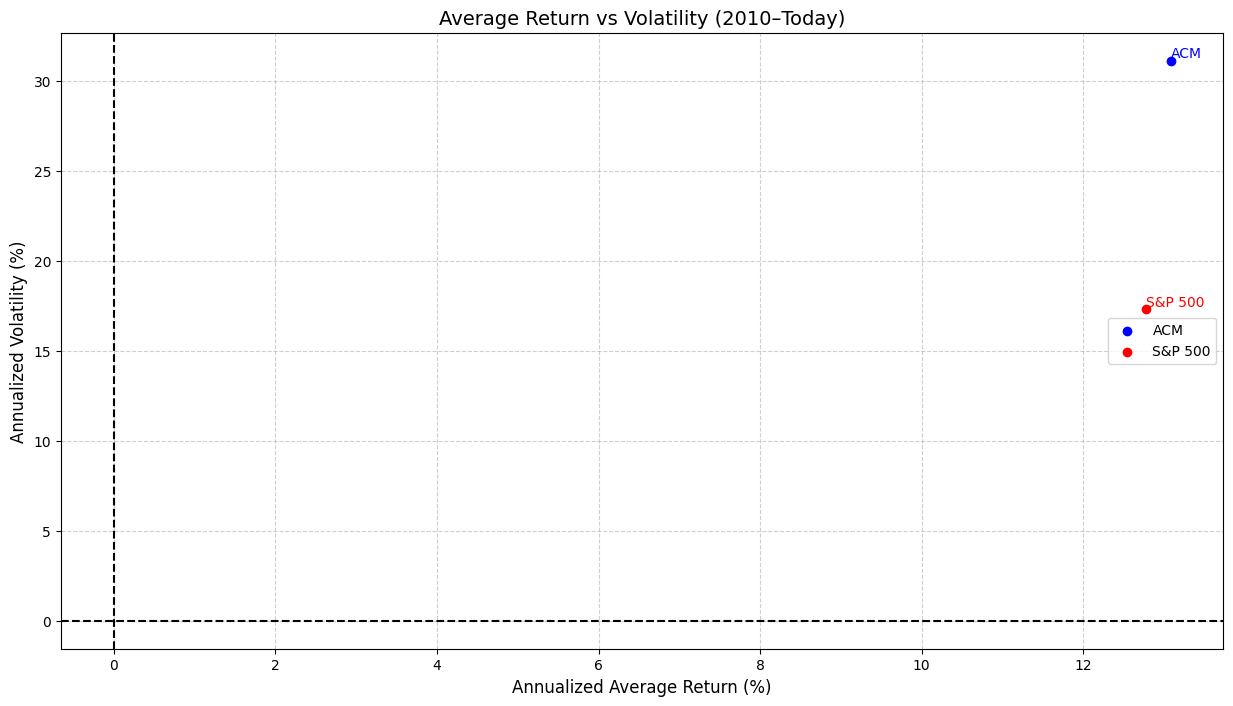

In [4]:
# Plot and save figure
#Example usage:
plot_avg_return_vs_volatility(
    stock_returns, benchmark_returns,
    stock_label=TICKER,
    benchmark_label="S&P 500",
    save_path=f"figures/{TICKER}_avg_return_vs_volatility.png"
)
